Temporary file to extract relevant data from various datasets

In [1]:
import geopandas as gpd
import os

# 1. Pfad zur GADM-Datei und Ausgabeordner
gadm_path = "gadm41_CHN.gpkg"  # Pfad zu deiner GADM-Datei
output_dir = "city_boundaries"  # Ordner für die Ausgabe
os.makedirs(output_dir, exist_ok=True)  # Erstelle den Ordner, falls nicht vorhanden

# 2. GADM-Daten laden (Layer ADM_ADM_2 = Präfektur-Städte)
gdf = gpd.read_file(gadm_path, layer="ADM_ADM_2")

# 3. Liste der gewünschten Städte (englische Namen)
target_cities = ["Beijing", "Chengdu", "Guangzhou", "Shanghai", "Shenyang"]

# 4. Filtere die Städte und speichere sie als GeoJSON
for city in target_cities:
    # Suche nach der Stadt im GADM-Datensatz (Spalte "NAME_2" enthält die Stadtnamen)
    city_gdf = gdf[gdf["NAME_2"] == city]

    # Falls die Stadt nicht gefunden wird, versuche alternative Schreibweisen
    if city_gdf.empty:
        # Alternative Schreibweisen (z. B. chinesische Namen oder Abkürzungen)
        alternatives = {
            "Beijing": ["北京市"],
            "Chengdu": ["成都市"],
            "Guangzhou": ["广州市"],
            "Shanghai": ["上海市"],
            "Shenyang": ["沈阳市"]
        }
        for alt_name in alternatives.get(city, []):
            city_gdf = gdf[gdf["NAME_2"] == alt_name]
            if not city_gdf.empty:
                break

    # Falls die Stadt immer noch nicht gefunden wird, überspringe sie
    if city_gdf.empty:
        print(f"⚠️ Stadt '{city}' nicht gefunden. Übersprungen.")
        continue

    # 5. Speichere die Stadtgrenze als GeoJSON
    output_path = os.path.join(output_dir, f"{city.lower()}_boundary.geojson")
    city_gdf.to_file(output_path, driver="GeoJSON")
    print(f"✅ Stadtgrenze für '{city}' gespeichert: {output_path}")

# 6. Optional: Alle Städte in einer einzigen Datei speichern
all_cities = gdf[gdf["NAME_2"].isin(target_cities)]
all_cities.to_file(os.path.join(output_dir, "all_cities_boundaries.geojson"), driver="GeoJSON")
print("✅ Alle Städte in einer Datei gespeichert: all_cities_boundaries.geojson")

✅ Stadtgrenze für 'Beijing' gespeichert: city_boundaries\beijing_boundary.geojson
✅ Stadtgrenze für 'Chengdu' gespeichert: city_boundaries\chengdu_boundary.geojson
✅ Stadtgrenze für 'Guangzhou' gespeichert: city_boundaries\guangzhou_boundary.geojson
✅ Stadtgrenze für 'Shanghai' gespeichert: city_boundaries\shanghai_boundary.geojson
✅ Stadtgrenze für 'Shenyang' gespeichert: city_boundaries\shenyang_boundary.geojson
✅ Alle Städte in einer Datei gespeichert: all_cities_boundaries.geojson


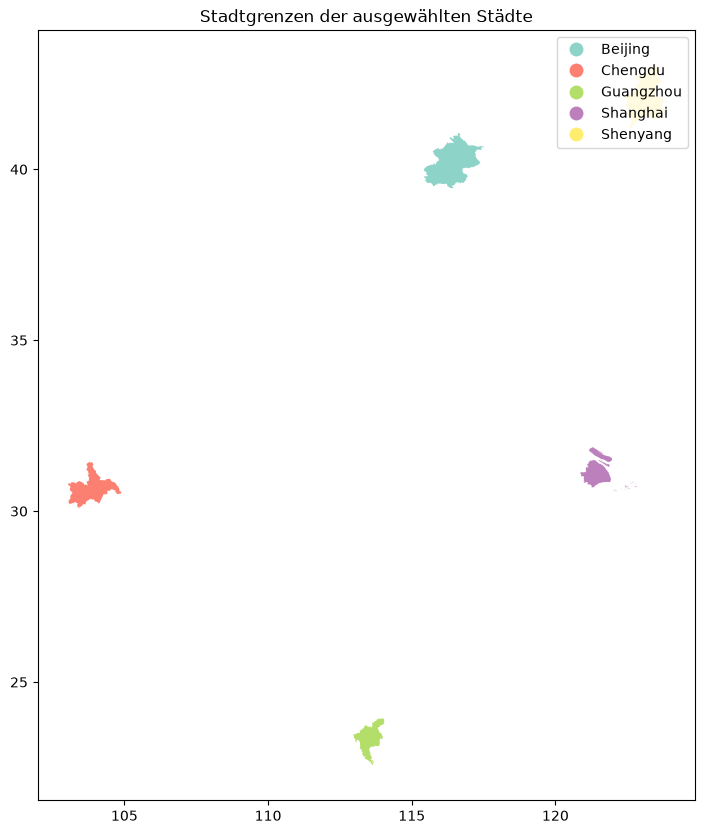

In [5]:
import matplotlib.pyplot as plt

# Lade alle extrahierten Städte
all_cities = gpd.read_file("city_boundaries/all_cities_boundaries.geojson")

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
all_cities.plot(ax=ax, column="NAME_2", legend=True, cmap="Set3")
plt.title("Stadtgrenzen der ausgewählten Städte")
plt.show()

In [14]:
import xarray as xr
import geopandas as gpd
import pandas as pd
import os
from tqdm import tqdm

# 1. Pfade und Konfiguration
edgar_dir = r"C:\Users\olive\Documents\EDGAR"
output_dir = "edgar_extracted"
os.makedirs(output_dir, exist_ok=True)

# 2. Stadtgrenzen laden und korrekte Puffer erstellen
cities = gpd.read_file("city_boundaries/all_cities_boundaries.geojson")

# In projiziertes CRS umwandeln
cities_projected = cities.to_crs("EPSG:3857")
cities_projected["geometry"] = cities_projected.geometry.buffer(444000)  # 4° ≈ 444 km
cities_buffered = cities_projected.to_crs("EPSG:4326")

# 3. Schadstoffe und Sektoren
pollutants = {
    "PM2_5": "PM2.5",
    "BC": "BC",
    "OC": "OC",
    "SO2": "SO2"
}
sectors = ["POWER_INDUSTRY", "BUILDINGS", "TRANSPORT"]
years = range(2010, 2016)

# 4. Funktion zum Extrahieren der EDGAR-Daten
def extract_edgar_for_city(city_name, city_geometry, pollutant, sector, years):
    """Extrahiert EDGAR-Daten mit korrekter Pufferberechnung."""
    dfs = []

    for year in years:
        file = os.path.join(edgar_dir, f"v8.1_FT2022_AP_{pollutant}_{year}_bkl_{sector}_emi.nc")

        if not os.path.exists(file):
            continue

        try:
            with xr.open_dataset(file, engine='netcdf4') as ds:
                # Räumliche Filterung
                city_data = ds.sel(
                    lat=slice(city_geometry.bounds[1], city_geometry.bounds[3]),
                    lon=slice(city_geometry.bounds[0], city_geometry.bounds[2])
                )

                # Emissionen aggregieren
                emissions_var = "emissions" if "emissions" in city_data else "emi"
                city_emissions = city_data[emissions_var].sum(dim=["lat", "lon"]).to_dataframe().reset_index()
                city_emissions["city"] = city_name
                city_emissions["year"] = year
                city_emissions["pollutant"] = pollutant
                city_emissions["sector"] = sector
                dfs.append(city_emissions)

        except Exception as e:
            print(f"⚠️ Fehler bei {file}: {str(e)}")

    return pd.concat(dfs) if dfs else None

# 5. Hauptschleife
for pollutant_key, pollutant_name in pollutants.items():
    pollutant_df = pd.DataFrame()

    for sector in sectors:
        for city in cities_buffered.itertuples():
            city_emissions = extract_edgar_for_city(
                city.NAME_2,
                city.geometry,
                pollutant_name,
                sector,
                years
            )

            if city_emissions is not None:
                pollutant_df = pd.concat([pollutant_df, city_emissions])

    if not pollutant_df.empty:
        output_file = os.path.join(output_dir, f"edgar_{pollutant_key.lower()}_4deg_buffer.csv")
        pollutant_df.to_csv(output_file, index=False)
        print(f"✅ Daten für {pollutant_key} gespeichert: {output_file}")

✅ Daten für PM2_5 gespeichert: edgar_extracted\edgar_pm2_5_4deg_buffer.csv
✅ Daten für BC gespeichert: edgar_extracted\edgar_bc_4deg_buffer.csv
✅ Daten für OC gespeichert: edgar_extracted\edgar_oc_4deg_buffer.csv
✅ Daten für SO2 gespeichert: edgar_extracted\edgar_so2_4deg_buffer.csv


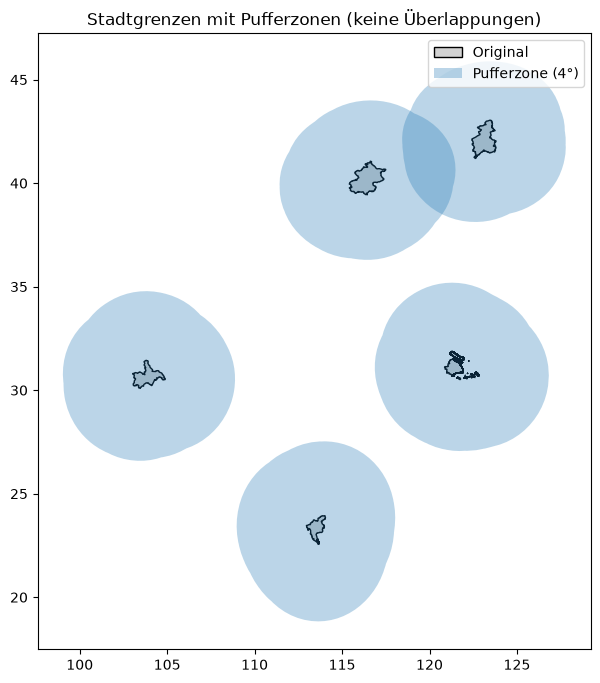

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
cities.plot(ax=ax, color="lightgrey", edgecolor="black", label="Original")
cities_buffered.plot(ax=ax, alpha=0.3, label="Pufferzone (4°)")
plt.title("Stadtgrenzen mit Pufferzonen (keine Überlappungen)")
plt.legend()
plt.show()

In [36]:
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import os

# 1. Überlappungsbereich berechnen (wie zuvor)
cities = gpd.read_file("city_boundaries/all_cities_boundaries.geojson")
cities_projected = cities.to_crs("EPSG:3857")
cities_projected["geometry"] = cities_projected.geometry.buffer(333960)
cities_buffered = cities_projected.to_crs("EPSG:4326")

beijing = cities_buffered[cities_buffered["NAME_2"] == "Beijing"].geometry.iloc[0]
shenyang = cities_buffered[cities_buffered["NAME_2"] == "Shenyang"].geometry.iloc[0]
overlap = beijing.intersection(shenyang)
print(f"Überlappungsbereich: {overlap.bounds}")

# 2. Funktion zum Extrahieren der Emissionen im Überlappungsbereich
def extract_overlap_emissions(edgar_dir, pollutant, sector, years, overlap_geom):
    results = []

    for year in years:
        file = os.path.join(edgar_dir, f"v8.1_FT2022_AP_{pollutant}_{year}_bkl_{sector}_emi.nc")

        if not os.path.exists(file):
            continue

        try:
            with xr.open_dataset(file, engine='netcdf4') as ds:
                # Räumliche Filterung nach Überlappungsbereich
                ds_filtered = ds.sel(
                    lat=slice(overlap_geom.bounds[1], overlap_geom.bounds[3]),
                    lon=slice(overlap_geom.bounds[0], overlap_geom.bounds[2])
                )

                # Monatliche Emissionen summieren
                yearly_emissions = ds_filtered['emissions'].sum(dim='time')

                # Gitterzellen im Überlappungsbereich identifizieren
                for lat in yearly_emissions.lat.values:
                    for lon in yearly_emissions.lon.values:
                        point = Point(lon, lat)
                        if overlap_geom.contains(point):
                            emission = float(yearly_emissions.sel(lat=lat, lon=lon, method='nearest').values)
                            if not np.isnan(emission):
                                results.append({
                                    'year': year,
                                    'lat': float(lat),
                                    'lon': float(lon),
                                    'emissions': emission
                                })

        except Exception as e:
            print(f"Fehler bei {file}: {str(e)}")

    return pd.DataFrame(results)

# 3. Hauptanalyse
edgar_dir = r"C:\Users\olive\Documents\EDGAR"
years = range(2010, 2016)
pollutant = "PM2.5"
sector = "POWER_INDUSTRY"

# Emissionen im Überlappungsbereich extrahieren
overlap_df = extract_overlap_emissions(edgar_dir, pollutant, sector, years, overlap)

if len(overlap_df) > 0:
    print(f"\nEmissionen im Überlappungsbereich:")
    print(f"Anzahl Gitterzellen: {len(overlap_df)}")
    print(f"Gesamtemissionen: {overlap_df['emissions'].sum():.2f} Mg")

    # Vergleich mit Gesamtemissionen
    print("\nVergleich mit Gesamtemissionen:")
    emissions_df = pd.read_csv("edgar_extracted/edgar_pm2_5_4deg_buffer.csv")
    city_totals = emissions_df.groupby('city')['emissions'].sum()

    for city in ["Beijing", "Shenyang"]:
        if city in city_totals:
            city_total = city_totals[city]
            print(f"{city} Gesamtemissionen: {city_total:.2f} Mg")
            overlap_share = overlap_df['emissions'].sum() * 0.5 / city_total * 100
            print(f"Geschätzter Überlappungsanteil: {overlap_share:.2f}%")
else:
    print("Keine Emissionen im Überlappungsbereich gefunden.")

Überlappungsbereich: (119.42321587234203, 39.72069082872323, 120.49920686964921, 42.37248806635186)

Emissionen im Überlappungsbereich:
Anzahl Gitterzellen: 990
Gesamtemissionen: 7057.49 Mg

Vergleich mit Gesamtemissionen:
Beijing Gesamtemissionen: 3303726.68 Mg
Geschätzter Überlappungsanteil: 0.11%
Shenyang Gesamtemissionen: 1972469.73 Mg
Geschätzter Überlappungsanteil: 0.18%


In [39]:
import pandas as pd
df = pd.read_csv('edgar_extracted/edgar_bc_4deg_buffer.csv')

# Die ersten 5 Zeilen anzeigen
print(df.head())

         time  emissions     city  year pollutant          sector
0  2010-01-15  186.56807  Beijing  2010        BC  POWER_INDUSTRY
1  2010-02-15  144.14015  Beijing  2010        BC  POWER_INDUSTRY
2  2010-03-15  179.39080  Beijing  2010        BC  POWER_INDUSTRY
3  2010-04-15  171.98795  Beijing  2010        BC  POWER_INDUSTRY
4  2010-05-15  168.19424  Beijing  2010        BC  POWER_INDUSTRY


In [40]:
import geopandas as gpd

# GeoJSON-Datei einlesen
gdf = gpd.read_file('city_boundaries/all_cities_boundaries.geojson')

# Alle Spaltennamen als Liste ausgeben
print(gdf.columns.tolist())

['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2', 'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2', 'geometry']


In [7]:
import xarray as xr
import geopandas as gpd
import pandas as pd
import os
import numpy as np
import time
import psutil

# 1. Konfiguration
edgar_dir = r"C:\Users\olive\Documents\EDGAR"
output_dir = "edgar_extracted_monthly"
os.makedirs(output_dir, exist_ok=True)

# 2. Stadtgrenzen laden
print("Lade Stadtgrenzen...")
cities = gpd.read_file("city_boundaries/all_cities_boundaries.geojson")
cities_projected = cities.to_crs("EPSG:3857")
cities_projected["geometry"] = cities_projected.geometry.buffer(444000)
cities_buffered = cities_projected.to_crs("EPSG:4326")

# 3. Parameter - vollständige Datenmenge
pollutants = {"PM2_5": "PM2.5", "BC": "BC", "OC": "OC", "SO2": "SO2"}
sectors = ["POWER_INDUSTRY", "BUILDINGS", "TRANSPORT"]
years = range(2010, 2016)  # 2010-2015

print(f"System: {psutil.cpu_count()} Kerne, {psutil.virtual_memory().total/1e9:.1f} GB RAM")

# 4. Funktion zum direkten Verarbeiten (ohne Multiprocessing)
def process_single_file(file, pollutant, sector, year, cities_data):
    """Verarbeitet eine Datei sequentiell"""
    results = []
    
    try:
        print(f"Verarbeite: {os.path.basename(file)}")
        
        # Datei öffnen
        ds = xr.open_dataset(file, engine='netcdf4')
        emissions_var = "emissions" if "emissions" in ds else "emi"

        # Alle Städte für diese Datei verarbeiten
        for city_name, city_geom in cities_data:
            try:
                # Räumliche Filterung
                city_data = ds.sel(
                    lat=slice(city_geom.bounds[1], city_geom.bounds[3]),
                    lon=slice(city_geom.bounds[0], city_geom.bounds[2])
                )

                # Gitterzellen verarbeiten
                lats = city_data.lat.values
                lons = city_data.lon.values
                emissions = city_data[emissions_var].values

                for i in range(len(lats)):
                    for j in range(len(lons)):
                        for month_idx in range(12):
                            emission = emissions[month_idx, i, j]
                            if not np.isnan(emission):
                                results.append({
                                    'city': city_name,
                                    'year': year,
                                    'month': month_idx + 1,
                                    'lat': float(lats[i]),
                                    'lon': float(lons[j]),
                                    'emissions': float(emission),
                                    'pollutant': pollutant,
                                    'sector': sector
                                })
            except Exception as e:
                print(f"Fehler bei Stadt {city_name}: {str(e)}")
                continue
                
        ds.close()
        
    except Exception as e:
        print(f"Fehler bei Datei {file}: {str(e)}")
        return pd.DataFrame()

    return pd.DataFrame(results)

# 5. Hauptverarbeitung - sequentiell
start_time = time.time()

# Vorbereitung
cities_data = [(city.NAME_2, city.geometry) for city in cities_buffered.itertuples()]
file_list = []

for pollutant_key, pollutant_name in pollutants.items():
    for sector in sectors:
        for year in years:
            file = os.path.join(edgar_dir, f"v8.1_FT2022_AP_{pollutant_name}_{year}_bkl_{sector}_emi.nc")
            if os.path.exists(file):
                file_list.append((file, pollutant_name, sector, year, cities_data))

print(f"Verarbeite {len(file_list)} Dateien sequentiell...")

# Verarbeitung
all_results = []
for i, (file, pollutant, sector, year, cities_data) in enumerate(file_list):
    print(f"[{i+1}/{len(file_list)}] Verarbeite {os.path.basename(file)}")
    result = process_single_file(file, pollutant, sector, year, cities_data)
    if not result.empty:
        all_results.append(result)
        print(f"  → {len(result)} Zeilen erzeugt")
    else:
        print(f"  → Keine Daten gefunden")

# Ergebnisse zusammenführen
if all_results:
    final_df = pd.concat(all_results, ignore_index=True)
    print(f"\nGesamt: {len(final_df)} Zeilen")
    
    # Speichern als komprimiertes Parquet
    try:
        output_file = os.path.join(output_dir, "edgar_all_pollutants_monthly.parquet")
        final_df.to_parquet(output_file, engine='fastparquet', compression='snappy')
        print(f"✅ Daten gespeichert: {output_file}")
        print(f"   Größe: {os.path.getsize(output_file)/1e6:.1f} MB")
    except ImportError:
        print("FastParquet nicht verfügbar, verwende CSV fallback...")
        output_file = os.path.join(output_dir, "edgar_all_pollutants_monthly.csv.gz")
        final_df.to_csv(output_file, index=False, compression='gzip')
        print(f"✅ CSV-Daten gespeichert: {output_file}")
        print(f"   Größe: {os.path.getsize(output_file)/1e6:.1f} MB")
        
else:
    print("Keine Ergebnisse erzeugt.")

print(f"\nGesamtlaufzeit: {time.time()-start_time:.1f} Sekunden")
print(f"CPU-Auslastung: {psutil.cpu_percent()}%")
print(f"RAM-Verbrauch: {psutil.virtual_memory().percent}%")

Lade Stadtgrenzen...
System: 16 Kerne, 34.3 GB RAM
Verarbeite 42 Dateien sequentiell...
[1/42] Verarbeite v8.1_FT2022_AP_PM2.5_2010_bkl_POWER_INDUSTRY_emi.nc
Verarbeite: v8.1_FT2022_AP_PM2.5_2010_bkl_POWER_INDUSTRY_emi.nc
  → 468912 Zeilen erzeugt
[2/42] Verarbeite v8.1_FT2022_AP_PM2.5_2011_bkl_POWER_INDUSTRY_emi.nc
Verarbeite: v8.1_FT2022_AP_PM2.5_2011_bkl_POWER_INDUSTRY_emi.nc
  → 468912 Zeilen erzeugt
[3/42] Verarbeite v8.1_FT2022_AP_PM2.5_2012_bkl_POWER_INDUSTRY_emi.nc
Verarbeite: v8.1_FT2022_AP_PM2.5_2012_bkl_POWER_INDUSTRY_emi.nc
  → 468912 Zeilen erzeugt
[4/42] Verarbeite v8.1_FT2022_AP_PM2.5_2013_bkl_POWER_INDUSTRY_emi.nc
Verarbeite: v8.1_FT2022_AP_PM2.5_2013_bkl_POWER_INDUSTRY_emi.nc
  → 468912 Zeilen erzeugt
[5/42] Verarbeite v8.1_FT2022_AP_PM2.5_2014_bkl_POWER_INDUSTRY_emi.nc
Verarbeite: v8.1_FT2022_AP_PM2.5_2014_bkl_POWER_INDUSTRY_emi.nc
  → 468912 Zeilen erzeugt
[6/42] Verarbeite v8.1_FT2022_AP_PM2.5_2015_bkl_POWER_INDUSTRY_emi.nc
Verarbeite: v8.1_FT2022_AP_PM2.5_2015_bkl_

In [ ]:
import pandas as pd

# Datei einlesen
df = pd.read_csv('hourly_profiles.csv')

# Filtern der Zeilen für China (CHN)
df_china = df[df['Country_code_A3'] == 'CHN']

# Speichern in neue Datei
df_china.to_csv('hourly_profiles_china.csv', index=False)

print(f"Es wurden {len(df_china)} Zeilen für China gefunden und gespeichert.")

FileNotFoundError: [Errno 2] No such file or directory: 'hourly_profiles.csv'